# Entendendo o Modelo Cox de Riscos Proporcionais

Este notebook explica o **básico** do modelo Cox, um dos modelos mais importantes em análise de sobrevivência.

## Por que o Cox é tão usado?

1. **Semi-paramétrico**: Não assume uma distribuição específica para os tempos
2. **Flexível**: Incorpora múltiplas variáveis explicativas
3. **Interpretável**: Os coeficientes têm interpretação direta como Hazard Ratios
4. **Robusto**: Funciona bem em muitas situações práticas


In [1]:
# Imports necessários
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.datasets import load_rossi

# Configurações
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup completo!")


Setup completo!


## 1. A Intuição do Modelo Cox

O modelo Cox decompõe o risco (hazard) em duas partes:

$$h(t|x) = h_0(t) \times \exp(\beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p)$$

Onde:
- $h(t|x)$ = risco no tempo $t$ para indivíduo com características $x$
- $h_0(t)$ = risco baseline (comum a todos)
- $\exp(\beta'x)$ = efeito multiplicativo das covariáveis

**Ideia chave**: O modelo separa o "quando" (baseline) do "quem" (covariáveis).


In [2]:
# Vamos criar um dataset sintético simples para ilustrar
n = 1000

# Variáveis explicativas
idade = np.random.normal(50, 10, n)  # Idade média 50, desvio 10
tratamento = np.random.binomial(1, 0.5, n)  # 50% recebem tratamento
gravidade = np.random.uniform(0, 1, n)  # Gravidade da condição (0-1)

# Gerar tempos de sobrevivência
# Vamos usar um modelo real onde:
# - Idade aumenta o risco (β_idade > 0)
# - Tratamento reduz o risco (β_tratamento < 0)
# - Gravidade aumenta o risco (β_gravidade > 0)

# Coeficientes verdadeiros
beta_idade = 0.02       # Cada ano aumenta o risco em 2%
beta_tratamento = -0.5  # Tratamento reduz o risco em ~40%
beta_gravidade = 1.0    # Gravidade alta dobra o risco

# Linear predictor
lp = (beta_idade * (idade - 50) + 
      beta_tratamento * tratamento + 
      beta_gravidade * gravidade)

# Gerar tempos (usando Weibull como verdade)
U = np.random.uniform(0, 1, n)
scale = 1000 * np.exp(-lp)  # Scale parameter
shape = 1.5  # Shape parameter
tempo_real = scale * (-np.log(U)) ** (1/shape)

# Adicionar censura (~30%)
tempo_censura = np.random.uniform(200, 2000, n)
tempo_observado = np.minimum(tempo_real, tempo_censura)
evento = (tempo_real <= tempo_censura).astype(int)

# Criar DataFrame
df = pd.DataFrame({
    'tempo': tempo_observado,
    'evento': evento,
    'idade': idade,
    'tratamento': tratamento,
    'gravidade': gravidade
})

print(f"Dataset criado com {n} observações")
print(f"Taxa de eventos: {evento.mean():.1%}")
print("\nPrimeiras linhas:")
print(df.head())


Dataset criado com 1000 observações
Taxa de eventos: 69.5%

Primeiras linhas:
        tempo  evento      idade  tratamento  gravidade
0  416.508738       1  54.967142           0   0.219069
1  472.601939       0  48.617357           0   0.036721
2  978.988672       0  56.476885           1   0.108026
3  314.179153       1  65.230299           1   0.338861
4  345.107729       0  47.658466           0   0.802586


## 2. Ajustando o Modelo Cox


In [13]:
# Criar e ajustar o modelo Cox
cph = CoxPHFitter()

# Ajustar o modelo
# duration_col: coluna com os tempos
# event_col: coluna com indicador de evento (1) ou censura (0)
cph.fit(df, duration_col='tempo', event_col='evento')

# Ver resumo do modelo
print("RESUMO DO MODELO COX:")
print("=" * 60)
cph.print_summary()


RESUMO DO MODELO COX:


<lifelines.CoxPHFitter: fitted with 1000 total observations, 305 right-censored observations>
             duration col = 'tempo'
                event col = 'evento'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 695
   partial log-likelihood = -4115.99
         time fit was run = 2025-10-18 19:52:01 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
idade       0.03      1.03      0.00            0.02            0.04                1.02                1.04
tratamento -0.73      0.48      0.08           -0.89           -0.58                0.41                0.56
gravidade   1.34      3.81      0.14            1.07            1.61                2.91                4.99

            cmp to     z      p  -log2(p)
covariate                                
idade         0.00  7.11 <0.005     39.66
tratamento    0.00 -9.38 <0.005     67.09
gravidade     0.00  9.73 <0.005     71.97
---
Concordance = 0.66
Partial AIC = 8237.97
log-likelihood ratio test = 214.42 on 3 df
-log2(p) of ll-ratio test = 151.12

## 3. Interpretando os Resultados

### Coeficientes (β)
- **Positivo**: aumenta o risco (reduz sobrevivência)
- **Negativo**: reduz o risco (aumenta sobrevivência)

### Hazard Ratios (HR = exp(β))
- **HR > 1**: fator de risco (ex: HR=2 → dobra o risco)
- **HR < 1**: fator protetor (ex: HR=0.5 → reduz risco pela metade)
- **HR = 1**: sem efeito


In [14]:
# Extrair e interpretar os resultados
print("\nINTERPRETAÇÃO DOS RESULTADOS:")
print("=" * 60)

# Verificar a estrutura dos intervalos de confiança
print("\nColunas disponíveis em confidence_intervals_:")
print(cph.confidence_intervals_.columns.tolist())

for var in cph.params_.index:
    coef = cph.params_[var]
    hr = np.exp(coef)
    
    # Acessar os intervalos de confiança pela posição (primeira coluna = lower, segunda = upper)
    ci_lower = np.exp(cph.confidence_intervals_.loc[var].iloc[0])
    ci_upper = np.exp(cph.confidence_intervals_.loc[var].iloc[1])
    p_value = cph.summary.loc[var, 'p']
    
    print(f"\n{var.upper()}:")
    print(f"  Coeficiente β = {coef:.3f}")
    print(f"  Hazard Ratio = {hr:.3f} (IC 95%: {ci_lower:.3f} - {ci_upper:.3f})")
    print(f"  p-value = {p_value:.4f}")
    
    # Interpretação
    if p_value < 0.05:
        if hr > 1:
            aumento = (hr - 1) * 100
            print(f"  → Aumenta o risco em {aumento:.1f}% (significativo)")
        else:
            reducao = (1 - hr) * 100
            print(f"  → Reduz o risco em {reducao:.1f}% (significativo)")
    else:
        print(f"  → Sem efeito significativo")

# Comparar com valores verdadeiros
print("\n" + "=" * 60)
print("VALORES VERDADEIROS (usados na simulação):")
print(f"  β_idade = {beta_idade} (HR = {np.exp(beta_idade):.3f})")
print(f"  β_tratamento = {beta_tratamento} (HR = {np.exp(beta_tratamento):.3f})")
print(f"  β_gravidade = {beta_gravidade} (HR = {np.exp(beta_gravidade):.3f})")



INTERPRETAÇÃO DOS RESULTADOS:

Colunas disponíveis em confidence_intervals_:
['95% lower-bound', '95% upper-bound']

IDADE:
  Coeficiente β = 0.028
  Hazard Ratio = 1.028 (IC 95%: 1.020 - 1.036)
  p-value = 0.0000
  → Aumenta o risco em 2.8% (significativo)

TRATAMENTO:
  Coeficiente β = -0.734
  Hazard Ratio = 0.480 (IC 95%: 0.412 - 0.559)
  p-value = 0.0000
  → Reduz o risco em 52.0% (significativo)

GRAVIDADE:
  Coeficiente β = 1.337
  Hazard Ratio = 3.809 (IC 95%: 2.910 - 4.986)
  p-value = 0.0000
  → Aumenta o risco em 280.9% (significativo)

VALORES VERDADEIROS (usados na simulação):
  β_idade = 0.02 (HR = 1.020)
  β_tratamento = -0.5 (HR = 0.607)
  β_gravidade = 1.0 (HR = 2.718)


## 4. Visualizando o Modelo Cox


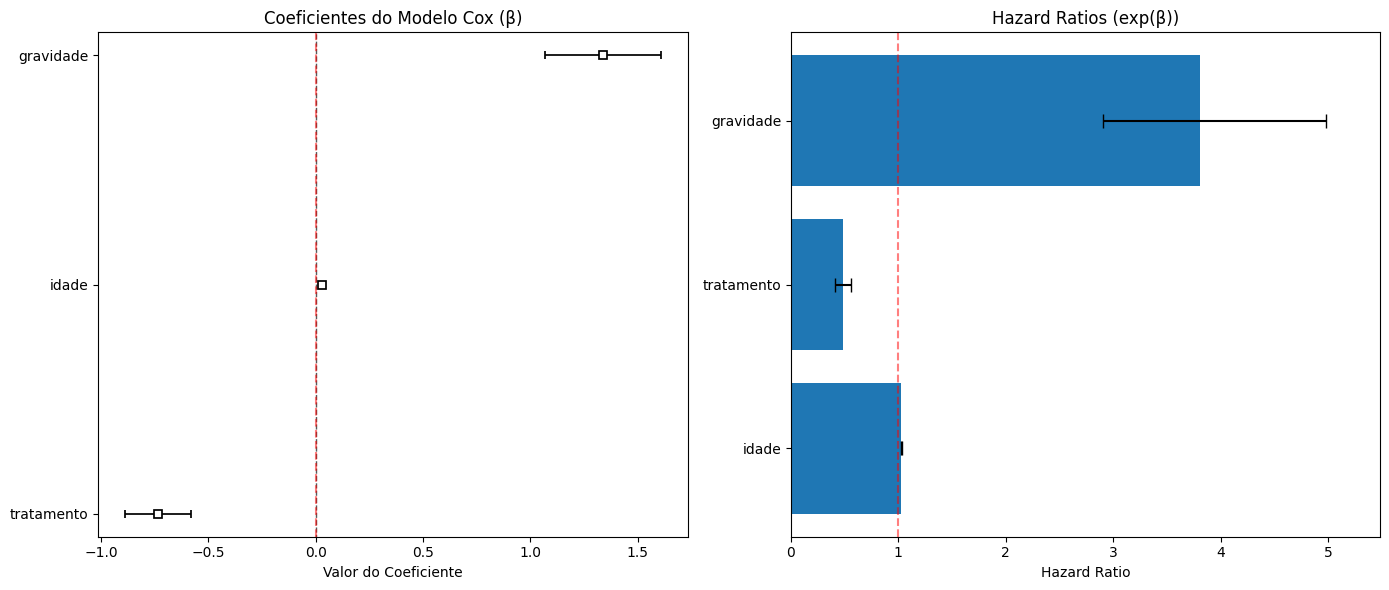

In [15]:
# Visualizar os coeficientes com intervalos de confiança
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Coeficientes
cph.plot(ax=ax1)
ax1.set_title('Coeficientes do Modelo Cox (β)')
ax1.axvline(0, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Valor do Coeficiente')

# Plot 2: Hazard Ratios
hr_data = pd.DataFrame({
    'HR': np.exp(cph.params_),
    'HR_lower': np.exp(cph.confidence_intervals_.iloc[:, 0]),
    'HR_upper': np.exp(cph.confidence_intervals_.iloc[:, 1])
})

y_pos = np.arange(len(hr_data))
ax2.barh(y_pos, hr_data['HR'], xerr=[hr_data['HR'] - hr_data['HR_lower'], 
                                      hr_data['HR_upper'] - hr_data['HR']], 
         capsize=5)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(hr_data.index)
ax2.axvline(1, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Hazard Ratio')
ax2.set_title('Hazard Ratios (exp(β))')
ax2.set_xlim(0, max(hr_data['HR_upper']) * 1.1)

plt.tight_layout()
plt.show()


## 5. Curvas de Sobrevivência Ajustadas


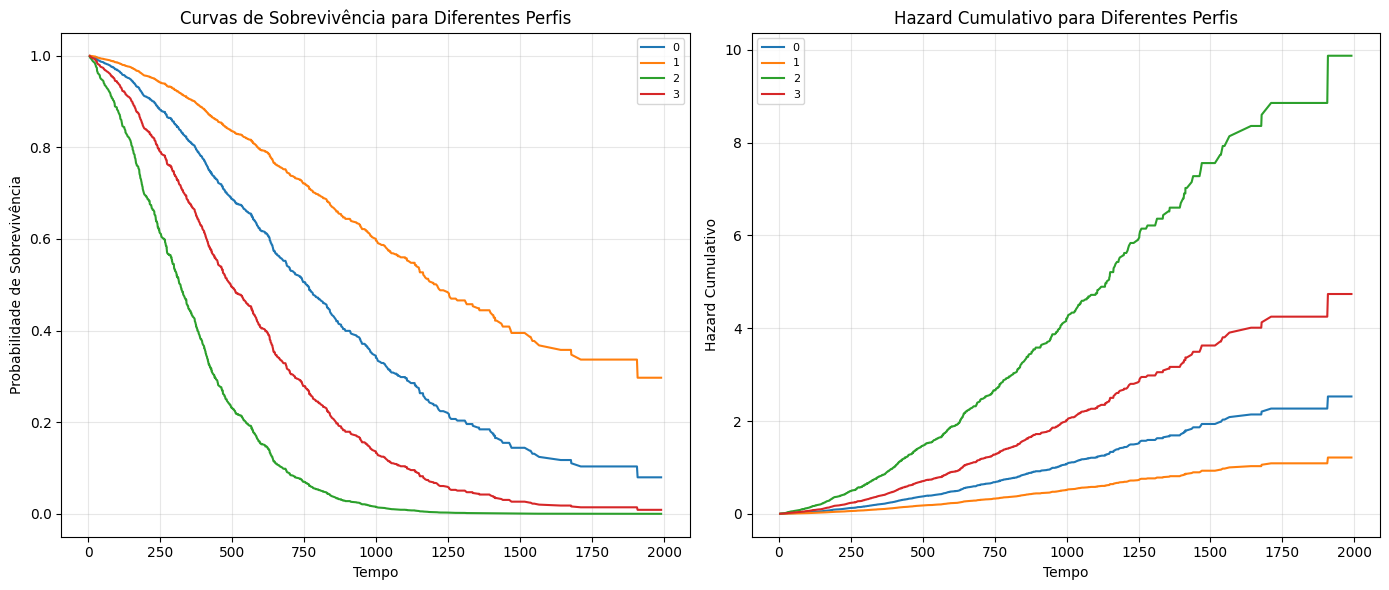

In [16]:
# Comparar curvas de sobrevivência para diferentes perfis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Criar perfis de pacientes
perfis = pd.DataFrame([
    {'idade': 40, 'tratamento': 0, 'gravidade': 0.2, 'label': 'Jovem, sem tratamento, baixa gravidade'},
    {'idade': 40, 'tratamento': 1, 'gravidade': 0.2, 'label': 'Jovem, com tratamento, baixa gravidade'},
    {'idade': 60, 'tratamento': 0, 'gravidade': 0.8, 'label': 'Idoso, sem tratamento, alta gravidade'},
    {'idade': 60, 'tratamento': 1, 'gravidade': 0.8, 'label': 'Idoso, com tratamento, alta gravidade'}
])

# Plot 1: Curvas de sobrevivência
for idx, perfil in perfis.iterrows():
    # Predizer curva de sobrevivência
    survival_func = cph.predict_survival_function(
        perfil[['idade', 'tratamento', 'gravidade']].to_frame().T
    )
    
    # Plotar
    survival_func.plot(ax=ax1, label=perfil['label'])

ax1.set_xlabel('Tempo')
ax1.set_ylabel('Probabilidade de Sobrevivência')
ax1.set_title('Curvas de Sobrevivência para Diferentes Perfis')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Hazard cumulativo
for idx, perfil in perfis.iterrows():
    # Predizer hazard cumulativo
    cumhaz_func = cph.predict_cumulative_hazard(
        perfil[['idade', 'tratamento', 'gravidade']].to_frame().T
    )
    
    # Plotar
    cumhaz_func.plot(ax=ax2, label=perfil['label'])

ax2.set_xlabel('Tempo')
ax2.set_ylabel('Hazard Cumulativo')
ax2.set_title('Hazard Cumulativo para Diferentes Perfis')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Baseline Hazard e Survival

O modelo Cox estima o hazard baseline $h_0(t)$ de forma não-paramétrica.


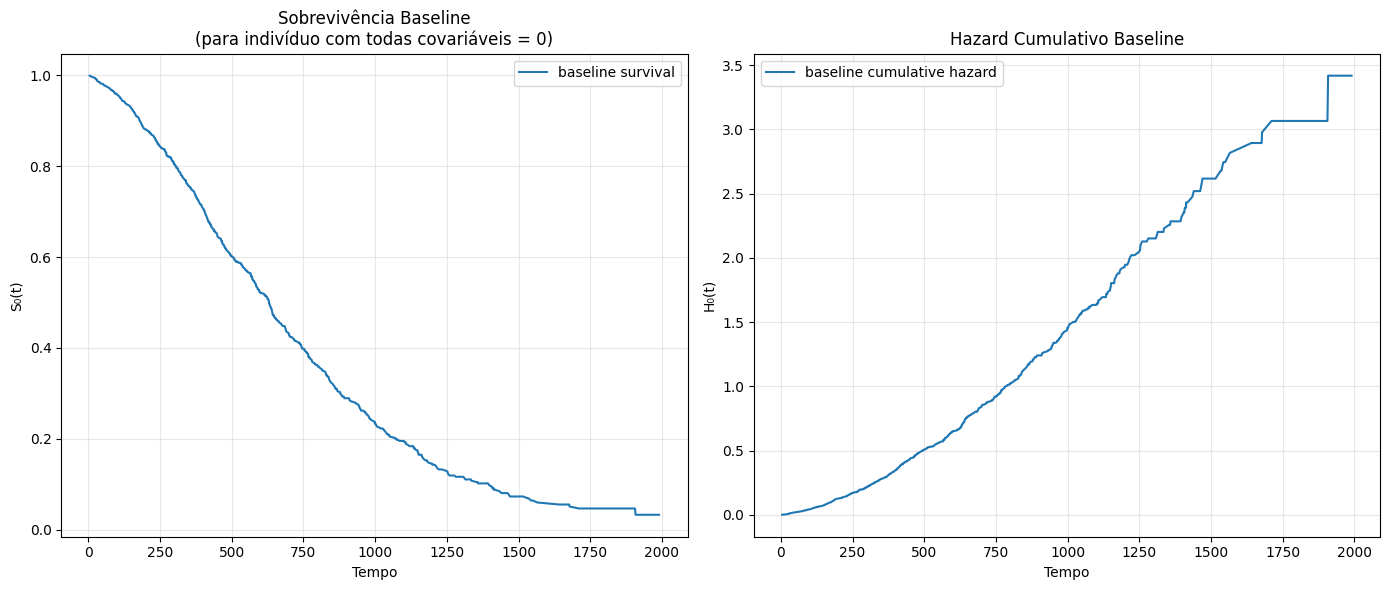

Nota: O baseline representa o risco para um indivíduo 'referência' com todas as covariáveis = 0


In [17]:
# Visualizar baseline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Baseline survival
cph.baseline_survival_.plot(ax=ax1)
ax1.set_xlabel('Tempo')
ax1.set_ylabel('S₀(t)')
ax1.set_title('Sobrevivência Baseline\n(para indivíduo com todas covariáveis = 0)')
ax1.grid(True, alpha=0.3)

# Baseline cumulative hazard
cph.baseline_cumulative_hazard_.plot(ax=ax2)
ax2.set_xlabel('Tempo')
ax2.set_ylabel('H₀(t)')
ax2.set_title('Hazard Cumulativo Baseline')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Nota: O baseline representa o risco para um indivíduo 'referência' com todas as covariáveis = 0")


## 7. Predições Individuais

Como usar o modelo para fazer predições para novos indivíduos?


NOVO PACIENTE:
   idade  tratamento  gravidade
0     55           1        0.6


Partial Hazard: 0.923
(Risco relativo comparado ao baseline)

PROBABILIDADE DE SOBREVIVÊNCIA:
  30 dias: 98.9%
  90 dias: 96.6%
  180 dias: 90.6%
  365 dias: 76.3%
  730 dias: 44.3%

Tempo mediano de sobrevivência: 646 dias


<Figure size 1000x600 with 0 Axes>

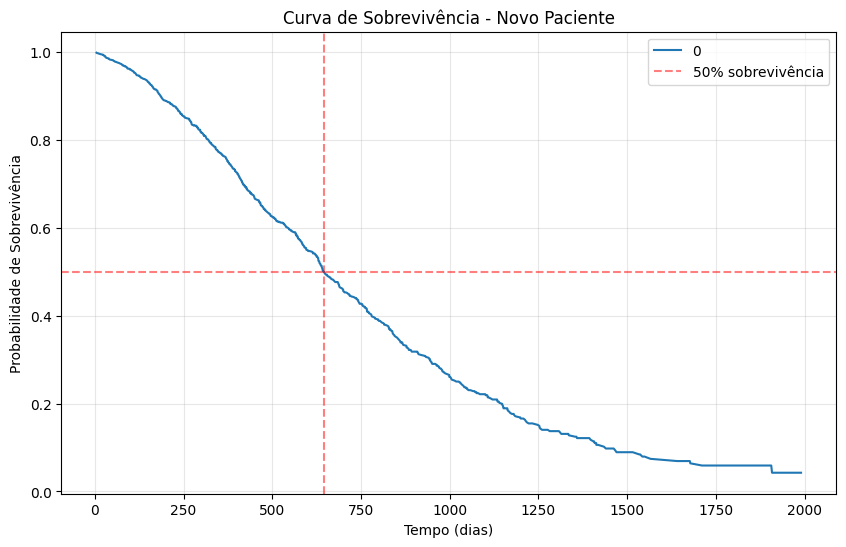

In [18]:
# Criar um novo paciente
novo_paciente = pd.DataFrame({
    'idade': [55],
    'tratamento': [1],
    'gravidade': [0.6]
})

print("NOVO PACIENTE:")
print(novo_paciente)
print("\n" + "="*60)

# 1. Partial hazard (risco relativo)
partial_hazard = cph.predict_partial_hazard(novo_paciente)
print(f"\nPartial Hazard: {partial_hazard.values[0]:.3f}")
print("(Risco relativo comparado ao baseline)")

# 2. Sobrevivência em tempos específicos
tempos_interesse = [30, 90, 180, 365, 730]
survival_probs = cph.predict_survival_function(novo_paciente, times=tempos_interesse)

print("\nPROBABILIDADE DE SOBREVIVÊNCIA:")
for t, prob in zip(tempos_interesse, survival_probs.values.flatten()):
    print(f"  {t} dias: {prob:.1%}")

# 3. Tempo mediano de sobrevivência
median_time = cph.predict_median(novo_paciente)
# Verificar se é DataFrame ou valor direto
if hasattr(median_time, 'values'):
    median_value = median_time.values[0]
else:
    median_value = float(median_time)
print(f"\nTempo mediano de sobrevivência: {median_value:.0f} dias")

# 4. Visualizar curva completa
plt.figure(figsize=(10, 6))
surv_curve = cph.predict_survival_function(novo_paciente)
surv_curve.plot()
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% sobrevivência')
plt.axvline(median_value, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Tempo (dias)')
plt.ylabel('Probabilidade de Sobrevivência')
plt.title('Curva de Sobrevivência - Novo Paciente')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Comparando com Kaplan-Meier

Vamos ver como o Cox se compara com o estimador não-paramétrico Kaplan-Meier.


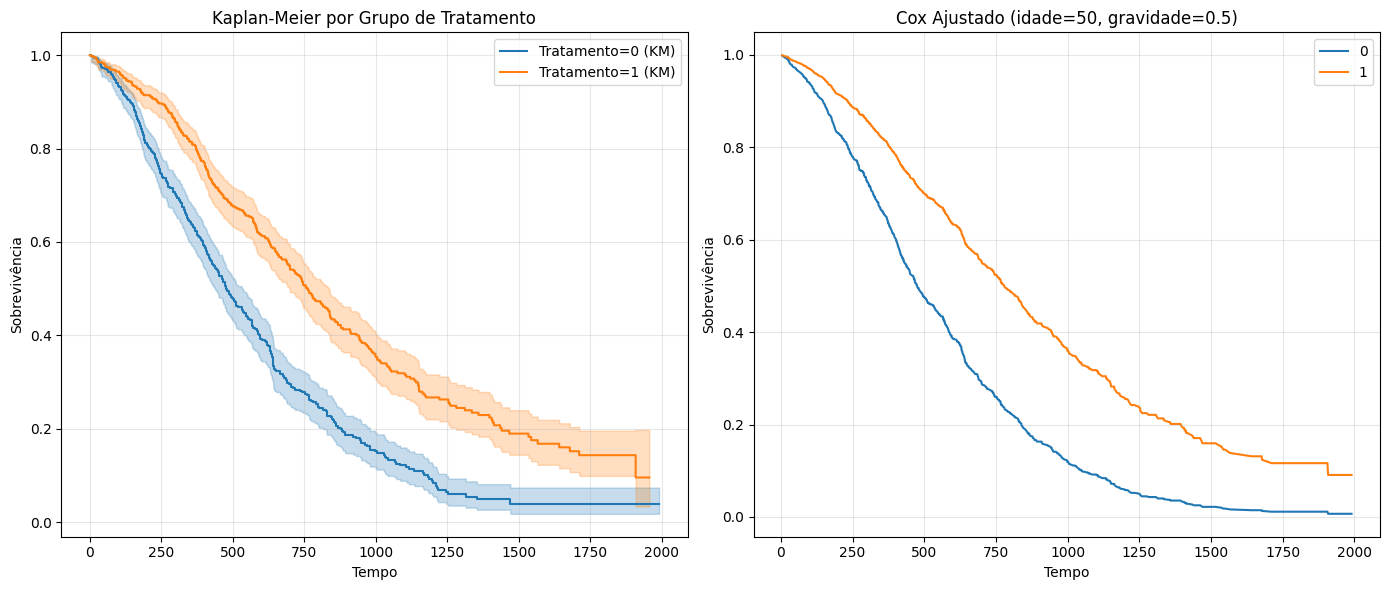

Nota: KM não ajusta para outras variáveis, Cox sim!


In [19]:
# Comparar Cox vs Kaplan-Meier para grupos de tratamento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Kaplan-Meier por grupo de tratamento
kmf = KaplanMeierFitter()

for trat in [0, 1]:
    mask = df['tratamento'] == trat
    label = f'Tratamento={trat} (KM)'
    kmf.fit(df.loc[mask, 'tempo'], df.loc[mask, 'evento'], label=label)
    kmf.plot_survival_function(ax=ax1)

ax1.set_xlabel('Tempo')
ax1.set_ylabel('Sobrevivência')
ax1.set_title('Kaplan-Meier por Grupo de Tratamento')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cox ajustado para idade=50, gravidade=0.5
perfil_base = pd.DataFrame({
    'idade': [50, 50],
    'tratamento': [0, 1],
    'gravidade': [0.5, 0.5]
})

for idx, row in perfil_base.iterrows():
    label = f'Tratamento={int(row["tratamento"])} (Cox ajustado)'
    surv = cph.predict_survival_function(row.to_frame().T)
    surv.plot(ax=ax2, label=label)

ax2.set_xlabel('Tempo')
ax2.set_ylabel('Sobrevivência')
ax2.set_title('Cox Ajustado (idade=50, gravidade=0.5)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Nota: KM não ajusta para outras variáveis, Cox sim!")


## 9. Teste da Suposição de Riscos Proporcionais

O modelo Cox assume que os hazard ratios são **constantes no tempo**. Vamos verificar isso.


In [20]:
# Teste de proporcionalidade
print("TESTE DE RISCOS PROPORCIONAIS:")
print("="*60)

# O teste verifica se há correlação entre os resíduos e o tempo
proportional_hazard_test = cph.check_assumptions(df, p_value_threshold=0.05, show_plots=False)

# Interpretação
print("\nInterpretação:")
print("- p-value < 0.05: violação da suposição (riscos NÃO proporcionais)")
print("- p-value > 0.05: suposição válida (riscos proporcionais)")
print("\nSe a suposição for violada, considere:")
print("  1. Estratificar pela variável problemática")
print("  2. Incluir interação com o tempo")
print("  3. Usar modelos alternativos (AFT, Random Survival Forest)")


TESTE DE RISCOS PROPORCIONAIS:
Proportional hazard assumption looks okay.

Interpretação:
- p-value < 0.05: violação da suposição (riscos NÃO proporcionais)
- p-value > 0.05: suposição válida (riscos proporcionais)

Se a suposição for violada, considere:
  1. Estratificar pela variável problemática
  2. Incluir interação com o tempo
  3. Usar modelos alternativos (AFT, Random Survival Forest)


## 10. Resumo e Conceitos-Chave

### Vantagens do Modelo Cox:
1. **Não precisa especificar distribuição** dos tempos
2. **Interpretação clara** via Hazard Ratios
3. **Múltiplas covariáveis** simultaneamente
4. **Baseline flexível** (não-paramétrico)

### Limitações:
1. Assume **riscos proporcionais**
2. Não extrapola bem além dos dados
3. Precisa de tamanho amostral razoável

### Quando usar Cox:
- Quando você tem múltiplas variáveis explicativas
- Quando não sabe a distribuição dos tempos
- Quando quer identificar fatores de risco/proteção
- Quando tem dados suficientes (>50-100 eventos)

### Fórmula fundamental:
$$h(t|x) = h_0(t) \times \exp(\beta'x)$$

Onde o **efeito das covariáveis é multiplicativo** no hazard!


In [21]:
# Exemplo final: calculando risco relativo entre dois perfis
perfil_A = pd.DataFrame({'idade': [60], 'tratamento': [0], 'gravidade': [0.8]})
perfil_B = pd.DataFrame({'idade': [40], 'tratamento': [1], 'gravidade': [0.2]})

hazard_A = cph.predict_partial_hazard(perfil_A).values[0]
hazard_B = cph.predict_partial_hazard(perfil_B).values[0]

risco_relativo = hazard_A / hazard_B

print("COMPARAÇÃO DE RISCO RELATIVO:")
print("="*60)
print("\nPerfil A: Idoso (60), sem tratamento, alta gravidade")
print("Perfil B: Jovem (40), com tratamento, baixa gravidade")
print(f"\nRisco relativo (A/B): {risco_relativo:.2f}")
print(f"\nInterpretação: Perfil A tem {risco_relativo:.1f}x mais risco que Perfil B")


COMPARAÇÃO DE RISCO RELATIVO:

Perfil A: Idoso (60), sem tratamento, alta gravidade
Perfil B: Jovem (40), com tratamento, baixa gravidade

Risco relativo (A/B): 8.13

Interpretação: Perfil A tem 8.1x mais risco que Perfil B
